# Set env

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import time
import os
import seaborn as sns
import psutil
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix,save_npz
from tqdm import tqdm
from itertools import combinations
from sklearn.metrics import mean_squared_error
from pyALRA import choose_k, alra
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, fontsize=18)

In [2]:
r_data_norm=pd.read_csv('/storage/Implem/pyALRA/pyALRA/data/data_test_normed_R.csv',sep=' ')
r_data_norm

,AL627309.1,RP11-206L10.2,LINC00115,NOC2L,KLHL17,HES4,ISG15,C1orf159,TTLL10,TNFRSF18,...,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AL592183.1,AC011841.1,PNRC2,SRSF10.1
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.499236,0.000000,0.0,2.134023,0.0,0.0,0.0,1.552739
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,1.696049,1.696049,0.0,3.470926,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,1.873284,0.0,0.0,0.000000,...,0.000000,0.000000,3.351594,1.873284,0.0,3.528061,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.323182,0.000000,2.966108,2.966108,0.0,3.633166,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,2.520524,1.904724,0.0,3.564034,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16422,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,1.948314,0.000000,1.948314,2.567538,0.0,2.947096,0.0,0.0,0.0,0.000000
16423,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.841349,...,3.101000,0.000000,2.828208,2.451874,0.0,2.451874,0.0,0.0,0.0,0.000000
16424,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,...,2.614342,1.991855,2.995099,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
16425,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.356230,...,1.753633,0.000000,3.538895,1.753633,0.0,3.389573,0.0,0.0,0.0,0.000000


In [ ]:
adata_norm=ad.AnnData(r_data_norm)
adata_norm

AnnData object with n_obs × n_vars = 16427 × 12776

In [6]:
k = choose_k(adata_norm.X)
print(k['k'])

14


In [7]:
adata_norm.layers['alra'] = alra(adata_norm.X, k['k'])['A_norm_rank_k_cor_sc']

Read matrix with 16427 cells and 12776 genes
Find the 0.001 quantile of each gene
Sweep


/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/pyALRA/core.py:117: RuntimeWarning: invalid value encountered in divide
  mu_1 = np.sum(A_norm_rank_k_cor, axis=0) / np.sum(A_norm_rank_k_cor != 0, axis=0)
/home/alexandre_lanau/miniconda3/envs/sc_gex_tcr_env/lib/python3.10/site-packages/pyALRA/core.py:118: RuntimeWarning: in

Scaling all except for 244 columns
0.00% of the values became negative in the scaling process and were set to zero
The matrix went from 5.11% nonzero to 75.19% nonzero


In [8]:
r_data=pd.read_csv('/storage/Implem/pyALRA/pyALRA/data/data_test_processed_R.csv',sep=' ',header=None)

/tmp/ipykernel_957676/4142870303.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,

In [9]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(adata_norm.layers['alra'],np.array(r_data.drop(index=0),dtype='float'))
print(mse)

0.057088874238712735


In [10]:
adata_norm.layers['r_alra']=r_data.drop(index=0)

In [11]:
adata_norm

AnnData object with n_obs × n_vars = 16427 × 12776
    layers: 'alra', 'r_alra'

# Heatmap

/tmp/ipykernel_957676/1199439603.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


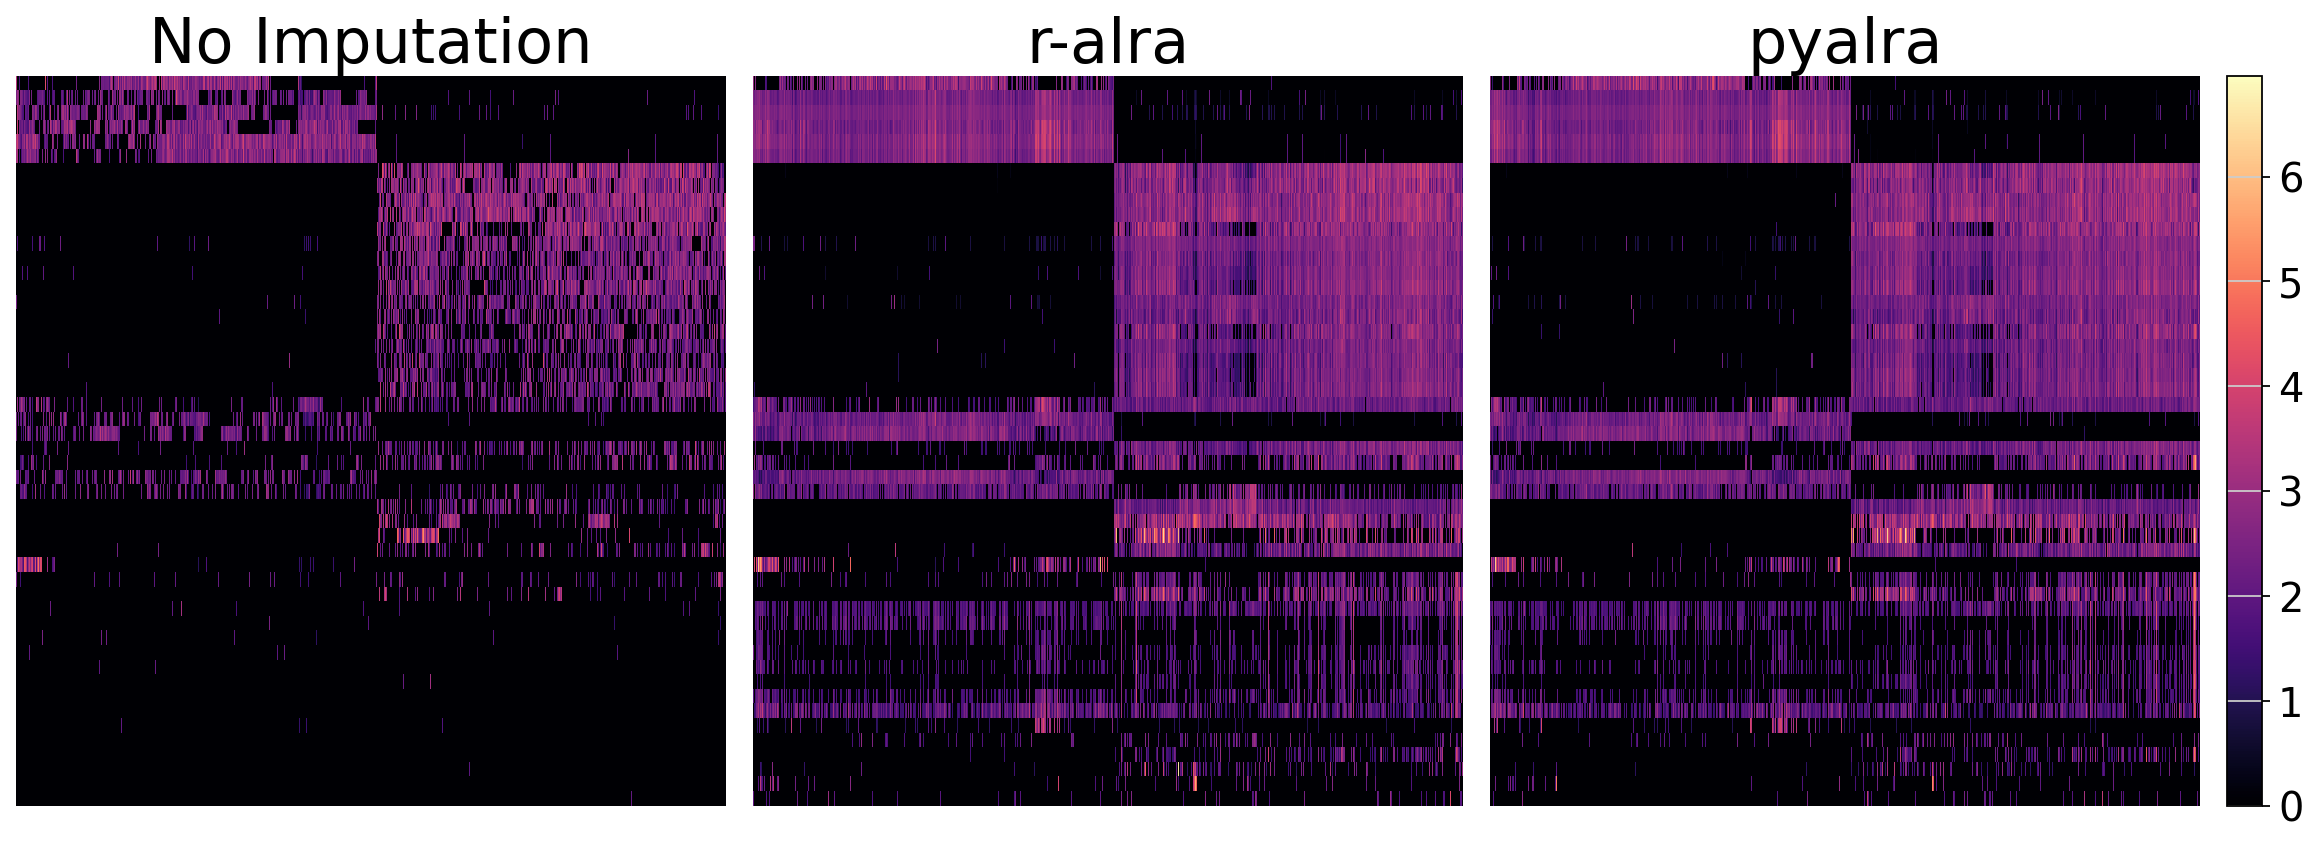

In [14]:
# # Step 1: Do NOT subset adata
# sc.pp.highly_variable_genes(adata_norm, layer='alra', n_top_genes=50, subset=False)

# # Step 2: Get list of 50 HVGs
# hvg_genes = adata_norm.var_names[adata_norm.var['highly_variable']]

# # Step 3: Define extraction function
# def get_expr_df(matrix, gene_names, cell_names):
#     if not isinstance(matrix, np.ndarray):
#         matrix = matrix.toarray()
#     df = pd.DataFrame(matrix, index=cell_names, columns=gene_names)
#     df = df[hvg_genes]  # keep only HVGs
#     df = df.T  # genes x cells
#     return df.astype(float)  # ensure numeric type

# # Step 4: Extract all matrices
# X_base = get_expr_df(adata_norm.X, adata_norm.var_names, adata_norm.obs_names)
# X_layer1 = get_expr_df(adata_norm.layers['r_alra'], adata_norm.var_names, adata_norm.obs_names)
# X_layer2 = get_expr_df(adata_norm.layers['alra'], adata_norm.var_names, adata_norm.obs_names)

# # Step 5: Compute clustering on one matrix
# g = sns.clustermap(X_base, row_cluster=True, col_cluster=True, cmap="magma",
#                    xticklabels=False, yticklabels=False, figsize=(10, 10),
#                    dendrogram_ratio=(0.1, 0.1), cbar_pos=None)

# # Step 6: Get dendrogram order
# gene_order = g.dendrogram_row.reordered_ind
# cell_order = g.dendrogram_col.reordered_ind

# # Step 7: Reorder matrices
# def reorder(df):
#     return df.iloc[gene_order, cell_order]

# matrices = {
#     "No Imputation": reorder(X_base),
#     "r-alra": reorder(X_layer1),
#     "pyalra": reorder(X_layer2)
# }

# # Step 8: Determine global color scale (vmin/vmax)
# vmin = min(df.values.min() for df in matrices.values())
# vmax = max(df.values.max() for df in matrices.values())

import matplotlib.gridspec as gridspec

# Step 9: Plot side-by-side heatmaps with shared colorbar
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.05)

# Shared color scale
vmin = min(df.values.min() for df in matrices.values())
vmax = max(df.values.max() for df in matrices.values())

axes = []
for i, (title, df) in enumerate(matrices.items()):
    ax = fig.add_subplot(gs[i])
    axes.append(ax)
    hm = sns.heatmap(df, ax=ax, cmap="magma", vmin=vmin, vmax=vmax,
                     xticklabels=False, yticklabels=False, cbar=False)
    ax.set_title(title,fontsize=28)

# Add colorbar on the 4th subplot position
cax = fig.add_subplot(gs[3])
plt.colorbar(hm.get_children()[0], cax=cax)

plt.tight_layout()
plt.savefig('/storage/Implem/pyALRA/pyALRA/plots/heatmaps/heatmap_HVGs_comparison.png', dpi=400)
plt.show()




# UMAP

In [10]:
color_palette={
        '0':'#1f77b4',
        '1':'#ff7f0e',
        '2':'#279e68',
        '3':'#d62728',
        '4':'#aa40fc',
        '5':'#8c564b',
        '6':'#e377c2',
        '7':'#b5bd61'
}

computing PCA
    with n_comps=50
    finished (0:00:27)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
running Leiden clustering


/tmp/ipykernel_600527/2744892872.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_norm,resolution=0.7,key_added='leiden_res_0.7_norm')


    finished: found 6 clusters and added
    'leiden_res_0.7_norm', the cluster labels (adata.obs, categorical) (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


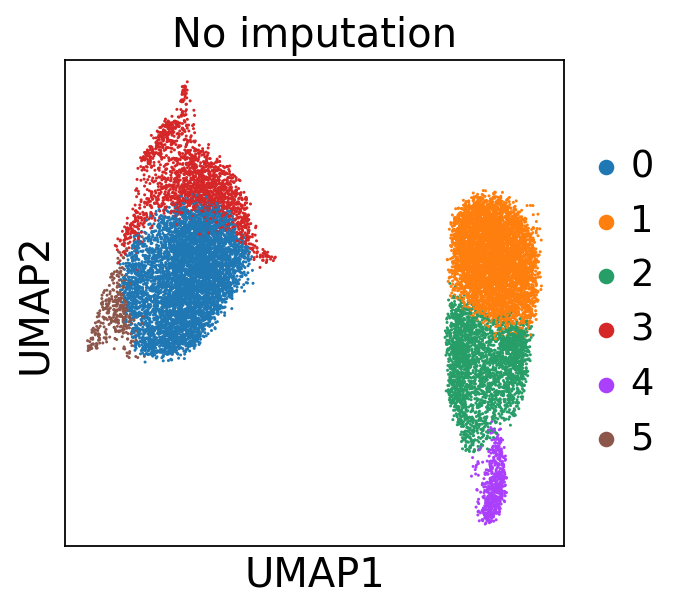

In [11]:
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.7,key_added='leiden_res_0.7_norm')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.7_norm',return_fig=True,title='No imputation',palette=color_palette)
plt.savefig('/storage/Implem/pyALRA/pyALRA/plots/umap_leiden_0.7_norm.pdf',bbox_inches='tight')

computing PCA
    with n_comps=50
    finished (0:00:13)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden_res_0.7_ralra', the cluster labels (adata.obs, categorical) (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


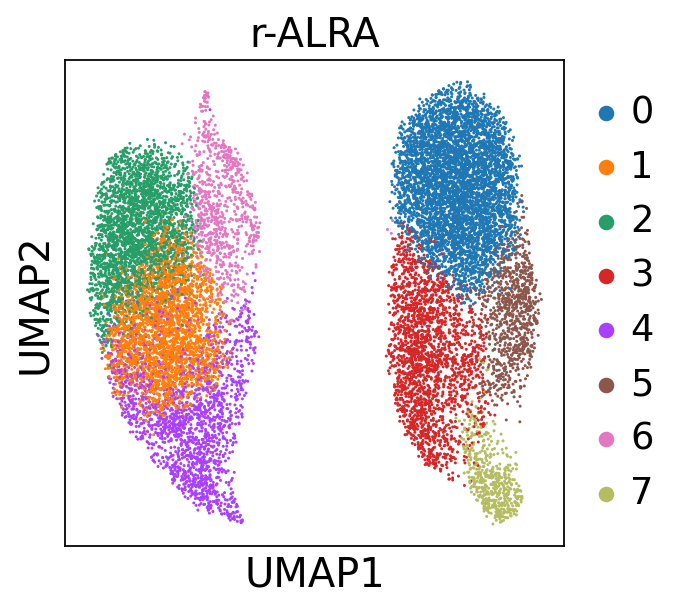

In [12]:
adata_norm.X=adata_norm.layers['r_alra']
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.7,key_added='leiden_res_0.7_ralra')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.7_ralra',return_fig=True,title='r-ALRA',palette=color_palette)
plt.savefig('/storage/Implem/pyALRA/pyALRA/plots/umap_leiden_0.7_ralra.pdf',bbox_inches='tight')

computing PCA
    with n_comps=50
    finished (0:00:11)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 8 clusters and added
    'leiden_res_0.7_pyalra', the cluster labels (adata.obs, categorical) (0:00:09)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:06)


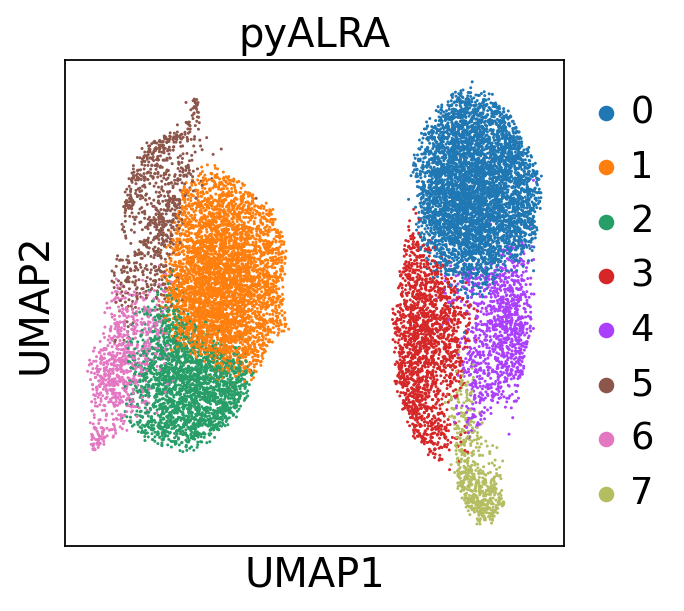

In [13]:
adata_norm.X=adata_norm.layers['alra']
sc.pp.pca(adata_norm)
sc.pp.neighbors(adata_norm)
sc.tl.leiden(adata_norm,resolution=0.7,key_added='leiden_res_0.7_pyalra')
sc.tl.umap(adata_norm)
sc.pl.umap(adata_norm, color='leiden_res_0.7_pyalra',return_fig=True,title='pyALRA',palette=color_palette)
plt.savefig('/storage/Implem/pyALRA/pyALRA/plots/umap_leiden_0.9_pyalra.pdf',bbox_inches='tight')

In [14]:
import plotly.graph_objects as go

# Define your custom color palette
color_palette = {
    '0': '#1f77b4',
    '1': '#ff7f0e',
    '2': '#279e68',
    '3': '#d62728',
    '4': '#aa40fc',
    '5': '#8c564b',
    '6': '#e377c2',
    '7': '#b5bd61'
}

# Specify the three obs columns you want to visualize
obs1 = "leiden_res_0.7_norm"  # Replace with actual column names
obs2 = "leiden_res_0.7_ralra"
obs3 = "leiden_res_0.7_pyalra"

# Extract relevant data
df = adata_norm.obs[[obs1, obs2, obs3]].dropna()

# Get unique categories for each column (cluster numbers)
categories1 = df[obs1].unique()
categories2 = df[obs2].unique()
categories3 = df[obs3].unique()

category_dict = {}
node_index = 0
for category in categories1:
    category_dict[f"{obs1}_{category}"] = node_index
    node_index += 1
for category in categories2:
    category_dict[f"{obs2}_{category}"] = node_index
    node_index += 1
for category in categories3:
    category_dict[f"{obs3}_{category}"] = node_index
    node_index += 1

# Function to map each category to a color from the color_palette
def map_color_to_category(category):
    return color_palette.get(str(category), '#888888')  # Default to gray if not found in palette

# Create color list for nodes based on the categories using the custom palette
node_colors = []
for category in categories1:
    node_colors.append(map_color_to_category(category))
for category in categories2:
    node_colors.append(map_color_to_category(category))
for category in categories3:
    node_colors.append(map_color_to_category(category))

# Create links (source, target, value)
links = []

# Define a function to add links between stages
def add_links(src_col, tgt_col):
    grouped = df.groupby([src_col, tgt_col]).size().reset_index(name="count")
    for _, row in grouped.iterrows():
        links.append({
            "source": category_dict[f"{src_col}_{row[src_col]}"],
            "target": category_dict[f"{tgt_col}_{row[tgt_col]}"],
            "value": row["count"]
        })

# Add links for each transition between columns
add_links(obs1, obs2)
add_links(obs2, obs3)

# Convert links into Sankey format
sankey_data = go.Sankey(
    node=dict(
        pad=2,
        thickness=10,
        line=dict(color="black", width=0.5),
        label=[""] * len(category_dict),  # Empty label to remove cluster names
        color=node_colors  # Apply colors to nodes
    ),
    link=dict(
        source=[l["source"] for l in links],
        target=[l["target"] for l in links],
        value=[l["value"] for l in links]
    )
)

# Add annotations to label each column (obs) at the top or bottom
annotations = [
    dict(
        x=-0.2,  # Adjust based on where the first column is placed
        y=1.15,  # Place it slightly above the top
        text='No Imputation',
        showarrow=False,
        font=dict(size=18)
    ),
    dict(
        x=0.5,  # Adjust based on where the second column is placed
        y=1.15,  # Place it slightly above the top
        text='r-ALRA',
        showarrow=False,
        font=dict(size=18)
    ),
    dict(
        x=1.15,  # Adjust based on where the third column is placed
        y=1.15,  # Place it slightly above the top
        text='py-ALRA',
        showarrow=False,
        font=dict(size=18)
    )
]

fig = go.Figure(sankey_data)
fig.update_layout(
    font_size=24,
    annotations=annotations,
    width=400,  # Reduce the width of the plot
    height=400  # You can adjust the height as well if needed
)

# Save the figure as a PDF
fig.write_image('/storage/Implem/pyALRA/pyALRA/plots/umap/alluvial.pdf', scale=2)

# Show the figure
fig.show()

/tmp/ipykernel_600527/118930776.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby([src_col, tgt_col]).size().reset_index(name="count")
/tmp/ipykernel_600527/118930776.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby([src_col, tgt_col]).size().reset_index(name="count")


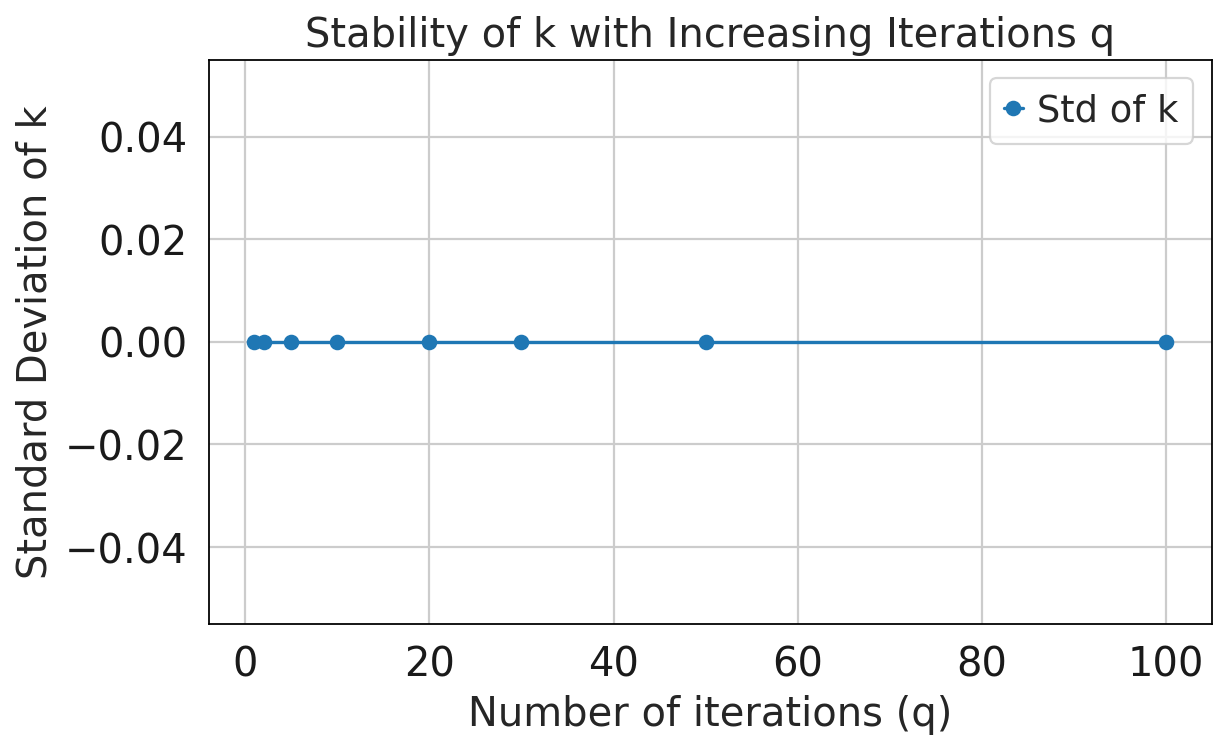

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(q_values, k_stds, marker='o', label='Std of k')
plt.xlabel('Number of iterations (q)')
plt.ylabel('Standard Deviation of k')
plt.title('Stability of k with Increasing Iterations q')
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.tight_layout()
# plt.savefig("std_k_vs_q.pdf", dpi=300)
plt.show()

# Benchmark computing efficiency

In [7]:
import math

def load_and_plot_benchmarks_combined(dataset, base_r_path, base_py_path, n_run, save_dir):
    """
    Load and plot benchmarks for combined datasets, saving each metric as a separate plot.

    Args:
        datasets (list of str): Names of the datasets.
        base_r_path (str): Base path to R benchmark results.
        base_py_path (str): Base path to Python benchmark results.
        n_run (int): Number of repetitions for each benchmark.
        save_dir (str): Directory where plots will be saved.
    """

    os.makedirs(save_dir, exist_ok=True)
    metrics = ['CPU_Hours', 'Memory_Usage_MB', 'k', 'Percent_Non_Zero']
    sns.set_theme(style="whitegrid", palette=None,font_scale=2)

    combined_df = pd.DataFrame()

    # for dataset in datasets:
    csv_r_path = os.path.join(base_r_path, dataset, "alra_benchmark_results.csv")
    csv_py_path = os.path.join(base_py_path, dataset, "alra_benchmark_results.csv")
    df_r = pd.read_csv(csv_r_path)
    df_py = pd.read_csv(csv_py_path)
    df_r['Source'] = 'R'
    df_py['Source'] = 'Python'
    combined_df = pd.concat([combined_df, df_r, df_py], ignore_index=True)


    melted_df = pd.melt(
        combined_df,
        id_vars=['Source', 'Number_of_Cells', 'Run'],
        value_vars=metrics,
        var_name='Metric',
        value_name='Value'
    )

    for metric in metrics:
        
        formatted_title = metric.replace("_", " ")
        
        plt.figure(figsize=(8, 6))

        if metric in ['CPU_Hours', 'Memory_Usage_MB']: 
            sns.lineplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                marker='o',
                palette={'Python':'#95190C','R':'#E3B505'},
                ci='sd',
                err_style='bars',
                linewidth=4,
                markersize=7, 
                err_kws={'elinewidth': 4}
            )
        else:  
            sns.barplot(
                data=melted_df[melted_df['Metric'] == metric],
                x='Number_of_Cells',
                y='Value',
                hue='Source',
                palette={'Python':'#95190C','R':'#E3B505'},
                ci='sd'  
            )

        if metric == 'CPU_Hours':
            print(metric)
            plt.title('Time of computation')
            plt.xticks(rotation=45)
            plt.ylabel('CPU/h')
        elif metric == 'Memory_Usage_MB':
            plt.title('Memory usage')
            plt.xticks(rotation=45)
            plt.ylabel('MB')
        else:
            plt.title(formatted_title)
            print(formatted_title)
            plt.ylabel('')
        
        
        plt.xlabel('Number of Cells')
        plt.legend(title='Source')
        plt.tight_layout()

        png_path = os.path.join(save_dir, f"{dataset}_combined_{metric}_plot.png")
        pdf_path = os.path.join(save_dir, f"{dataset}_combined_{metric}_plot.pdf")
        plt.savefig(png_path,dpi=200)
        plt.savefig(pdf_path,dpi=200)
        plt.close()

base_r_path = "/storage/Implem/pyALRA/pyALRA/benchmarks/alra_benchmark_results/R"
base_py_path = "/storage/Implem/pyALRA/pyALRA/benchmarks/alra_benchmark_results/python"
save_dir = "/storage/Implem/pyALRA/pyALRA/plots/benchmark_datasets"
n_run = 5

for dataset in ["E-MTAB-8142", "E-MTAB-7407", "E-GEOD-139324"]:
    load_and_plot_benchmarks_combined(dataset, base_r_path, base_py_path, n_run, save_dir)

/tmp/ipykernel_398135/2524645843.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


CPU_Hours


/tmp/ipykernel_398135/2524645843.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_398135/2524645843.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


k


/tmp/ipykernel_398135/2524645843.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


...

k
Percent Non Zero


/tmp/ipykernel_398135/2524645843.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


CPU_Hours


/tmp/ipykernel_398135/2524645843.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_398135/2524645843.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_398135/2524645843.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


k
Percent Non Zero


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from itertools import combinations

def load_matrices_by_size(python_dir, r_dir):
    """Load prediction matrices and group them by dataset size based on the matrix shape."""
    python_matrices_by_size = {}
    r_matrices_by_size = {}

    # Load Python matrices
    for file in tqdm(sorted(os.listdir(python_dir))):
        if file.endswith(".h5ad"):
            adata = ad.read_h5ad(os.path.join(python_dir, file))
            matrix = adata.layers['alra'].toarray() if hasattr(adata.layers['alra'], "toarray") else adata.layers['alra']
            size = matrix.shape[0]  # Use the number of rows as the size
            python_matrices_by_size.setdefault(size, []).append(matrix)

    # Load R matrices
    for file in tqdm(sorted(os.listdir(r_dir))):
        if file.endswith(".csv"):
            matrix = pd.read_csv(os.path.join(r_dir, file), index_col=False).values
            size = matrix.shape[0]  # Use the number of rows as the size
            r_matrices_by_size.setdefault(size, []).append(matrix)

    return python_matrices_by_size, r_matrices_by_size

def compute_mse(matrix1, matrix2):
    """Compute Mean Squared Error (MSE) between two matrices."""
    return mean_squared_error(matrix1, matrix2)

def analyze_and_plot_mse_by_size(dataset_name, python_dir, r_dir, output_dir):
    """Load matrices, compute MSEs, and plot results by dataset size."""
    dataset_output_dir = os.path.join(output_dir, dataset_name)
    os.makedirs(dataset_output_dir, exist_ok=True)

    # Load prediction matrices grouped by size
    python_matrices_by_size, r_matrices_by_size = load_matrices_by_size(python_dir, r_dir)

    for size in tqdm(sorted(python_matrices_by_size.keys())):
        # Matrices for the current size
        python_matrices = python_matrices_by_size[size]
        r_matrices = r_matrices_by_size.get(size, [])

        # Compute pairwise MSEs
        mse_within_py = [
            compute_mse(python_matrices[i], python_matrices[j])
            for i, j in combinations(range(len(python_matrices)), 2)
        ]
        mse_within_r = [
            compute_mse(r_matrices[i], r_matrices[j])
            for i, j in combinations(range(len(r_matrices)), 2)
        ]
        mse_between_r_py = [
            compute_mse(r_matrices[i], python_matrices[j])
            for i in range(len(r_matrices))
            for j in range(len(python_matrices))
        ]

        # Combine data for the current size
        mse_data = [
            {'Category': 'Within Python', 'MSE': mse} for mse in mse_within_py
        ] + [
            {'Category': 'Within R', 'MSE': mse} for mse in mse_within_r
        ] + [
            {'Category': 'Between R and Python', 'MSE': mse} for mse in mse_between_r_py
        ]

        # Heatmap for the current size
        heatmap_png_file = os.path.join(dataset_output_dir, f'heatmap_{size}_cells.png')
        heatmap_pdf_file = os.path.join(dataset_output_dir, f'heatmap_{size}_cells.pdf')
        plot_heatmaps(size, python_matrices, r_matrices, heatmap_png_file, heatmap_pdf_file)

        # Bar plot for the current size
        barplot_png_file = os.path.join(dataset_output_dir, f'barplot_{size}_cells.png')
        barplot_pdf_file = os.path.join(dataset_output_dir, f'barplot_{size}_cells.pdf')
        plot_mse_barplot(mse_data, size, barplot_png_file, barplot_pdf_file)

def plot_heatmaps(size, python_matrices, r_matrices, save_png_path, save_pdf_path):
    """Generate heatmaps for a given dataset size and save the plot."""
    n_py = len(python_matrices)
    n_r = len(r_matrices)

    mse_matrix_py = np.zeros((n_py, n_py))
    mse_matrix_r = np.zeros((n_r, n_r))
    mse_matrix_r_py = np.zeros((n_r, n_py))

    for i, j in combinations(range(n_py), 2):
        mse_matrix_py[i, j] = mse_matrix_py[j, i] = compute_mse(python_matrices[i], python_matrices[j])

    for i, j in combinations(range(n_r), 2):
        mse_matrix_r[i, j] = mse_matrix_r[j, i] = compute_mse(r_matrices[i], r_matrices[j])

    for i in range(n_r):
        for j in range(n_py):
            mse_matrix_r_py[i, j] = compute_mse(r_matrices[i], python_matrices[j])

    # Plot heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.heatmap(mse_matrix_py, ax=axes[0], cmap='viridis', annot=True, fmt='.2f')
    axes[0].set_title(f'MSE Heatmap (Within Python) - {size} Cells')
    axes[0].set_xlabel('Run')
    axes[0].set_ylabel('Run')

    sns.heatmap(mse_matrix_r, ax=axes[1], cmap='viridis', annot=True, fmt='.2f')
    axes[1].set_title(f'MSE Heatmap (Within R) - {size} Cells')
    axes[1].set_xlabel('Run')
    axes[1].set_ylabel('Run')

    sns.heatmap(mse_matrix_r_py, ax=axes[2], cmap='viridis', annot=True, fmt='.2f')
    axes[2].set_title(f'MSE Heatmap (Between R and Python) - {size} Cells')
    axes[2].set_xlabel('Python Run')
    axes[2].set_ylabel('R Run')

    plt.tight_layout()
    plt.savefig(save_png_path)
    plt.savefig(save_pdf_path)
    plt.close()

def plot_mse_barplot(mse_data, size, save_png_path, save_pdf_path):
    """Generate a bar plot for MSE data of a specific size and save the plot."""
    mse_df = pd.DataFrame(mse_data)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
    plt.title(f'Mean MSE Across Categories - {size} Cells')
    plt.ylabel('Mean MSE')
    plt.xlabel('Category')
    plt.tight_layout()
    plt.savefig(save_png_path)
    plt.savefig(save_pdf_path)
    plt.close()

# Example usage
base_python_dir = "/storage/Implem/pyALRA/pyALRA/benchmarks/alra_benchmark_results/python"
base_r_dir = "/storage/Implem/pyALRA/pyALRA/benchmarks/alra_benchmark_results/R"
output_dir = "/storage/Implem/pyALRA/pyALRA/plots"

datasets = ["E-MTAB-7407", "E-GEOD-139324"]

for dataset in datasets:
    python_dir = os.path.join(base_python_dir, dataset, "bench_runs")
    r_dir = os.path.join(base_r_dir, dataset, "bench_runs")
    analyze_and_plot_mse_by_size(dataset, python_dir, r_dir, output_dir)


  0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
 33%|███▎      | 1/3 [00:16<00:33, 16.91s/it]/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=mse_df, x='Category', y='MSE', ci='sd', palette='flare')
/tmp/ipykernel_31077/836995006.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for 

KeyboardInterrupt: 

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


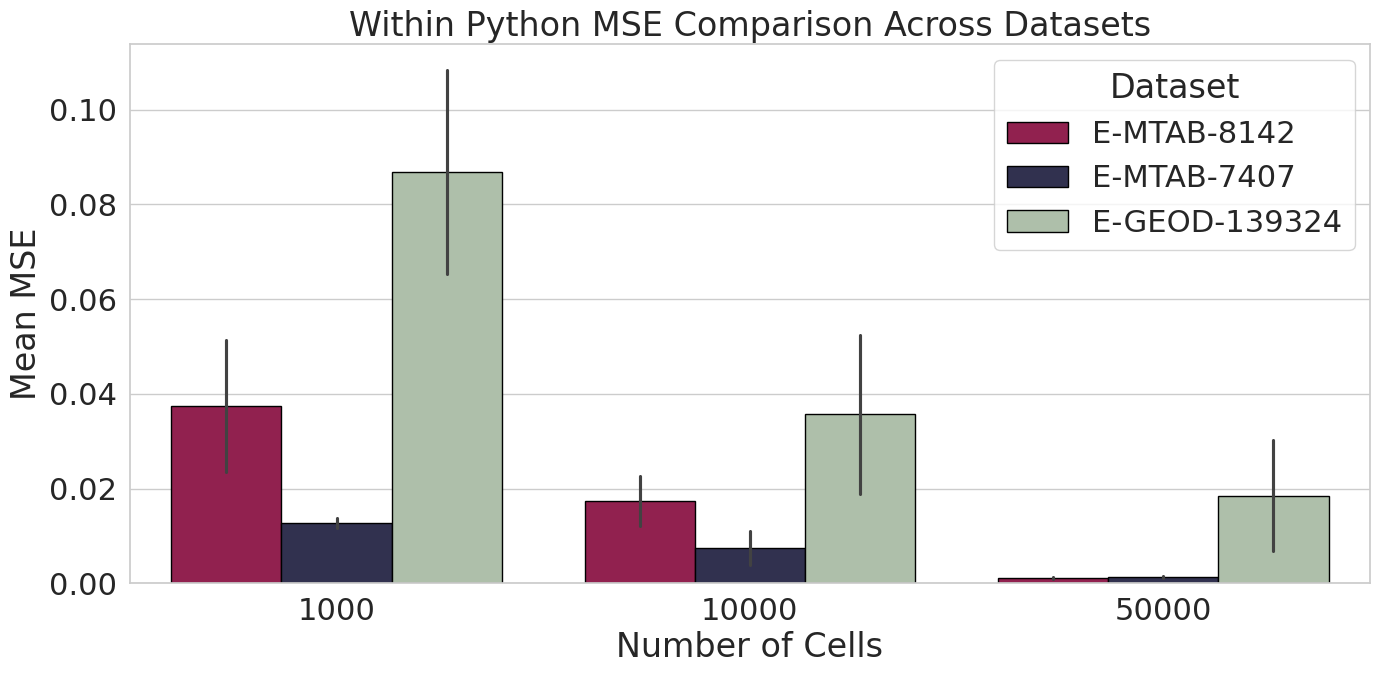

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


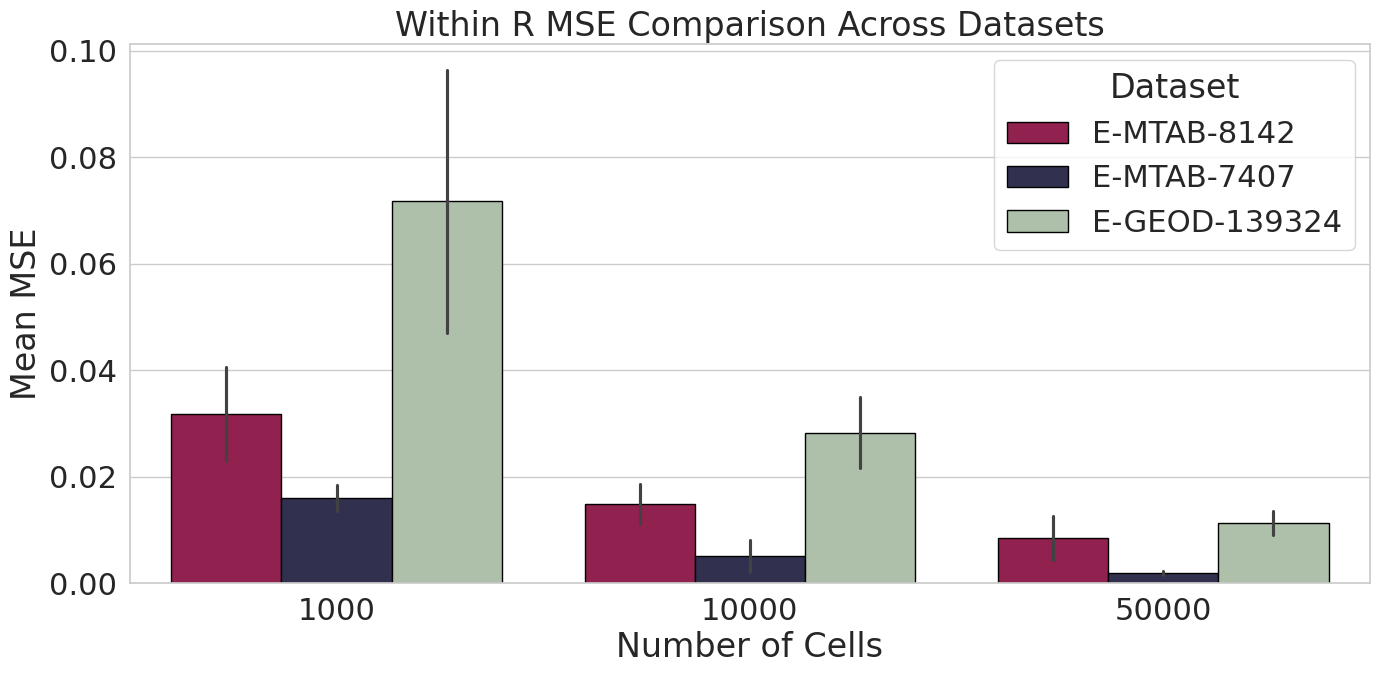

/tmp/ipykernel_13061/81276833.py:92: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


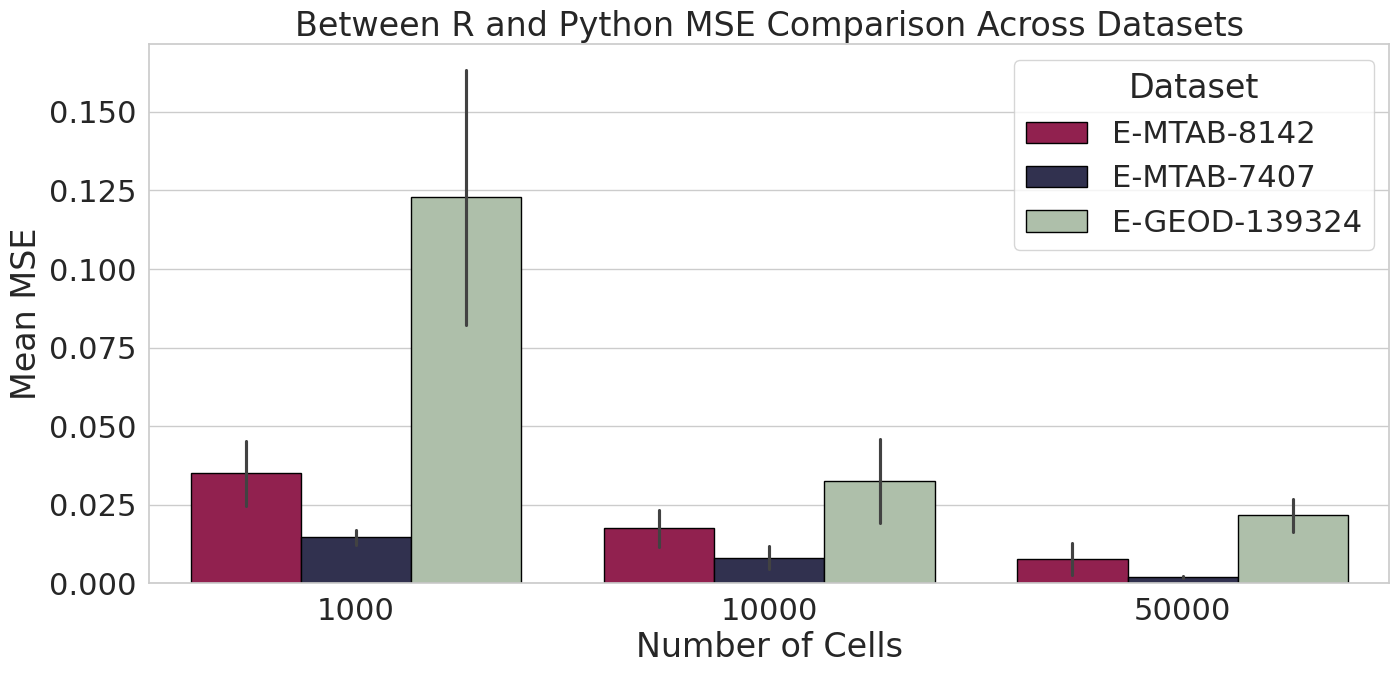

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


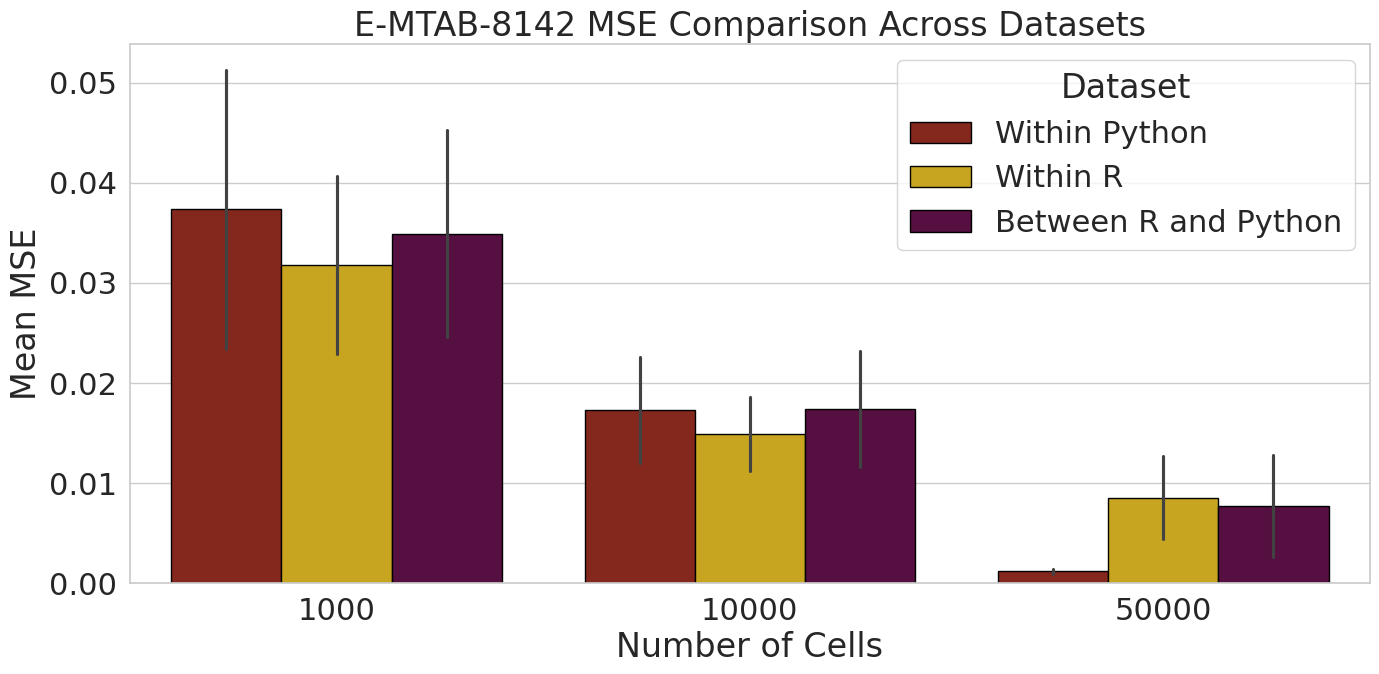

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


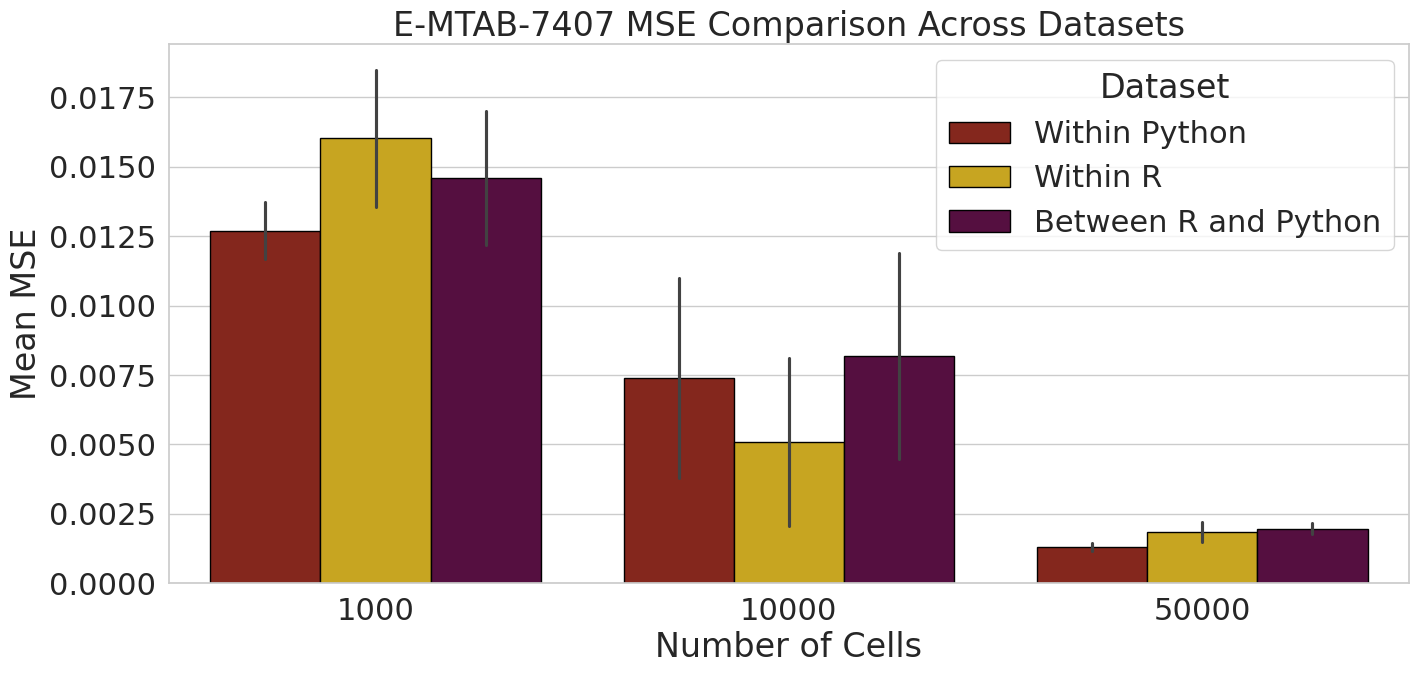

/tmp/ipykernel_13061/81276833.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


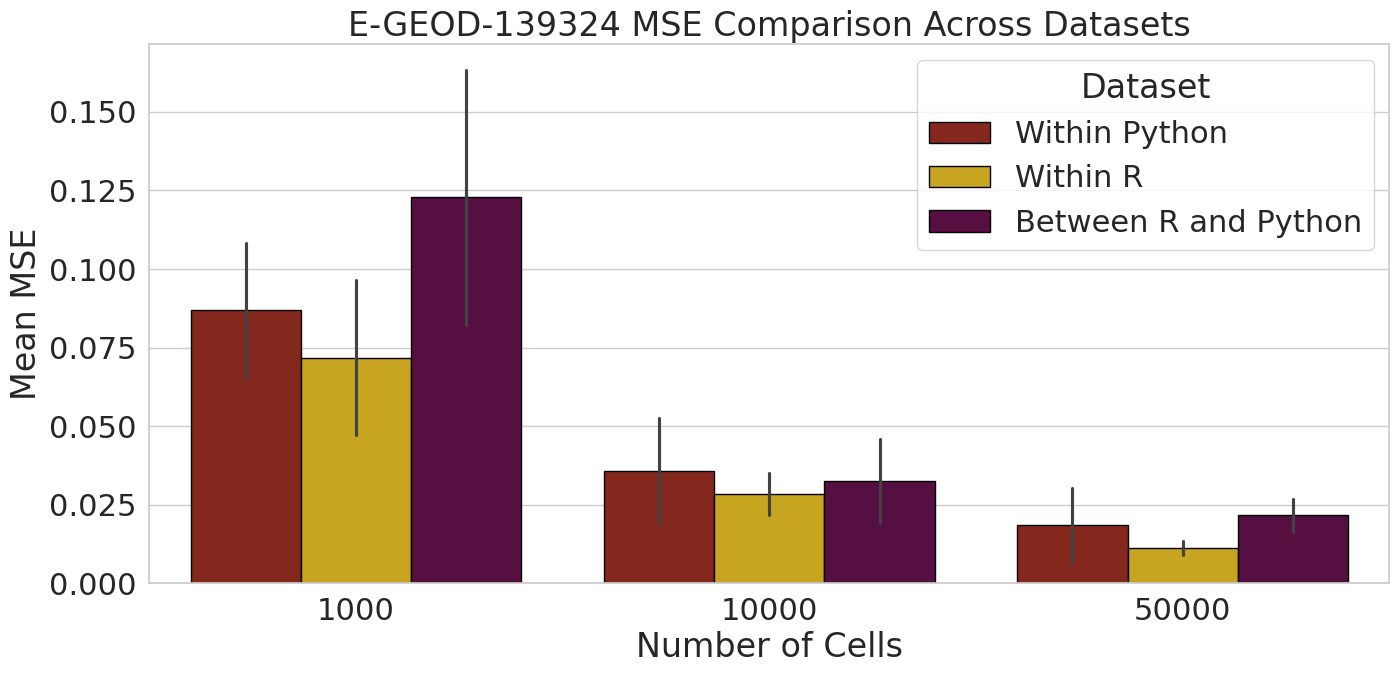

/tmp/ipykernel_13061/81276833.py:129: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


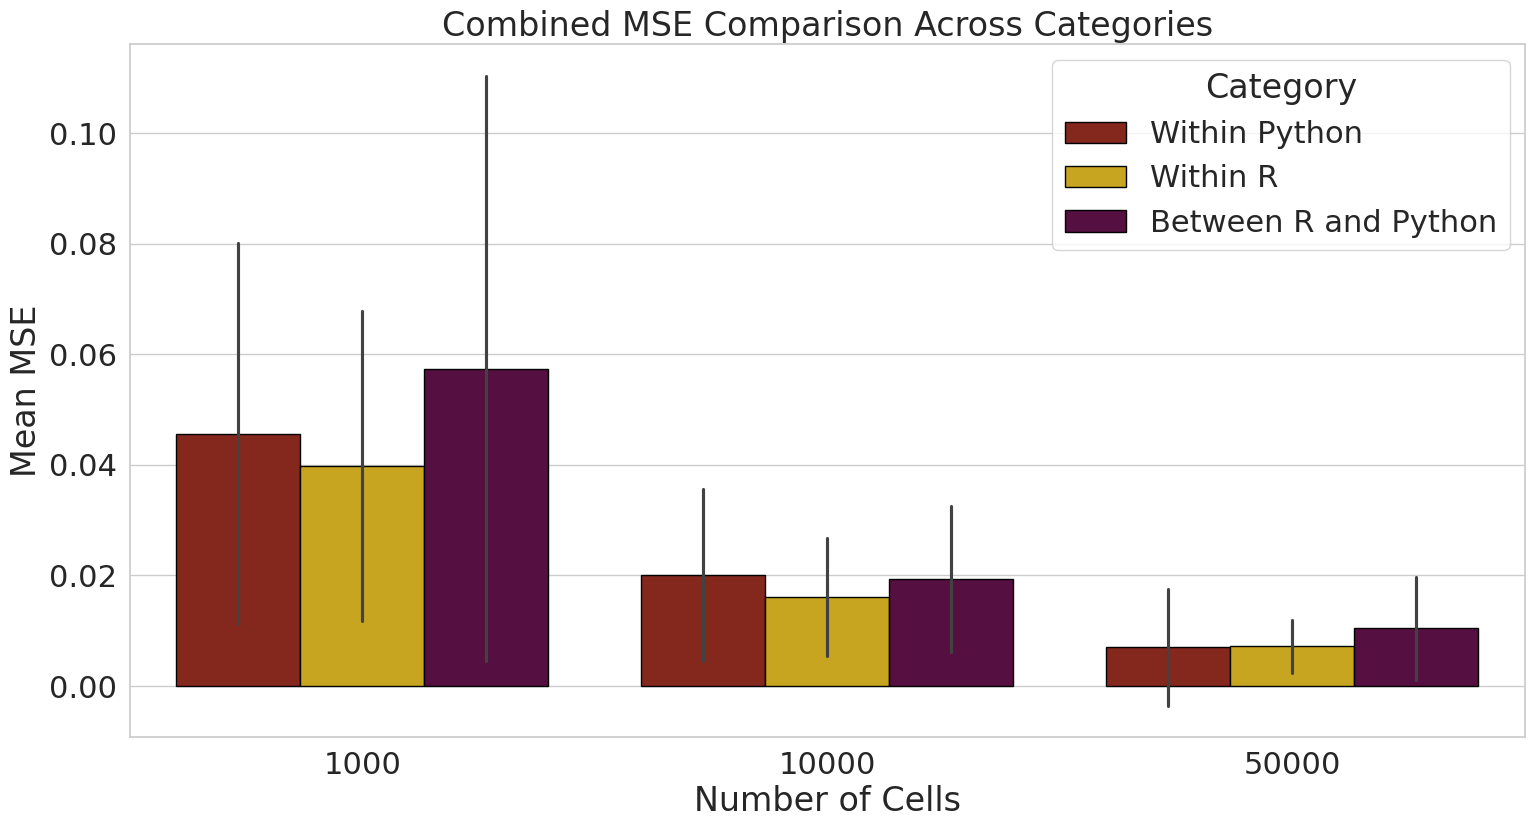

In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from itertools import combinations

def load_matrices_by_size(python_dir, r_dir):
    """Load prediction matrices and group them by dataset size based on the matrix shape."""
    python_matrices_by_size = {}
    r_matrices_by_size = {}

    # Load Python matrices
    for file in tqdm(sorted(os.listdir(python_dir))):
        if file.endswith(".h5ad"):
            adata = ad.read_h5ad(os.path.join(python_dir, file))
            matrix = adata.layers['alra'].toarray() if hasattr(adata.layers['alra'], "toarray") else adata.layers['alra']
            size = matrix.shape[0]  # Use the number of rows as the size
            python_matrices_by_size.setdefault(size, []).append(matrix)

    # Load R matrices
    for file in tqdm(sorted(os.listdir(r_dir))):
        if file.endswith(".csv"):
            matrix = pd.read_csv(os.path.join(r_dir, file), index_col=False).values
            size = matrix.shape[0]  # Use the number of rows as the size
            r_matrices_by_size.setdefault(size, []).append(matrix)

    return python_matrices_by_size, r_matrices_by_size

def compute_mse(matrix1, matrix2):
    """Compute Mean Squared Error (MSE) between two matrices."""
    return mean_squared_error(matrix1.flatten(), matrix2.flatten())

def compute_mse_for_datasets(dataset_dirs):
    """Compute MSEs for all datasets and subdatasets."""
    all_mse_results = []

    for dataset_name, (python_dir, r_dir) in dataset_dirs.items():
        print(f"Processing dataset: {dataset_name}")
        python_matrices_by_size, r_matrices_by_size = load_matrices_by_size(python_dir, r_dir)

        for size in tqdm(sorted(python_matrices_by_size.keys())):
            if size not in r_matrices_by_size:
                continue

            python_matrices = python_matrices_by_size[size]
            r_matrices = r_matrices_by_size[size]

            # Within Python
            for i, j in combinations(range(len(python_matrices)), 2):
                mse = compute_mse(python_matrices[i], python_matrices[j])
                all_mse_results.append({
                    'Dataset': dataset_name,
                    'Size': size,
                    'Category': 'Within Python',
                    'MSE': mse
                })

            # Within R
            for i, j in combinations(range(len(r_matrices)), 2):
                mse = compute_mse(r_matrices[i], r_matrices[j])
                all_mse_results.append({
                    'Dataset': dataset_name,
                    'Size': size,
                    'Category': 'Within R',
                    'MSE': mse
                })

            # Between R and Python
            for i, r_matrix in enumerate(r_matrices):
                for j, py_matrix in enumerate(python_matrices):
                    mse = compute_mse(r_matrix, py_matrix)
                    all_mse_results.append({
                        'Dataset': dataset_name,
                        'Size': size,
                        'Category': 'Between R and Python',
                        'MSE': mse
                    })

    return pd.DataFrame(all_mse_results)

def plot_mse_results(mse_df, save_dir):
    """Generate bar plots for MSE results."""
    mse_df['Size'] = mse_df['Size'].astype(str)  # Convert size to string for better plotting
    sns.set_theme(style="whitegrid", palette=None,font_scale=2)

    # Plot for each category separately by dataset
    for category in mse_df['Category'].unique():
        plt.figure(figsize=(16, 7))
        sns.barplot(
            data=mse_df[mse_df['Category'] == category],
            x='Size', y='MSE', hue='Dataset',
            ci='sd', palette={'E-MTAB-8142': '#A40E4C', 'E-MTAB-7407': '#2C2C54', 'E-GEOD-139324': '#ACC3A6'},
            edgecolor='black'
        )
        plt.title(f'{category} MSE Comparison Across Datasets')
        plt.ylabel('Mean MSE')
        plt.xlabel('Number of Cells')
        plt.legend(title='Dataset', loc='upper right')
        png_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.png")
        pdf_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.pdf")
        plt.savefig(png_path, format='png')
        plt.savefig(pdf_path, format='pdf')
        plt.show()
        
    # Plot for each category separately by dataset
    for category in mse_df['Dataset'].unique():
        plt.figure(figsize=(16, 7))
        sns.barplot(
            data=mse_df[mse_df['Dataset'] == category],
            x='Size', y='MSE', hue='Category',
            ci='sd', palette={'Within Python':'#95190C','Within R':'#E3B505','Between R and Python':'#610345'},
            edgecolor='black'
        )
        plt.title(f'{category} MSE Comparison Across Datasets')
        plt.ylabel('Mean MSE')
        plt.xlabel('Number of Cells')
        plt.legend(title='Dataset', loc='upper right')
        png_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.png")
        pdf_path = os.path.join(save_dir, f"{category.replace(' ', '_').lower()}_mse_plot.pdf")
        plt.savefig(png_path, format='png')
        plt.savefig(pdf_path, format='pdf')
        plt.show()

    # Combined plot across all categories
    plt.figure(figsize=(18, 9))
    sns.barplot(
        data=mse_df, x='Size', y='MSE', hue='Category',
        ci='sd', palette={'Within Python':'#95190C','Within R':'#E3B505','Between R and Python':'#610345'}, edgecolor='black'
    )
    plt.title('Combined MSE Comparison Across Categories')
    plt.ylabel('Mean MSE')
    plt.xlabel('Number of Cells')
    plt.legend(title='Category', loc='upper right')
    png_path = os.path.join(save_dir, "combined_mse_plot.png")
    pdf_path = os.path.join(save_dir, "combined_mse_plot.pdf")
    plt.savefig(png_path, format='png')
    plt.savefig(pdf_path, format='pdf')
    plt.show()

# Main Execution
dataset_dirs = {
    "E-MTAB-8142": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-MTAB-8142/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-MTAB-8142/bench_runs/"
    ),
    "E-MTAB-7407": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-MTAB-7407/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-MTAB-7407/bench_runs/"
    ),
    "E-GEOD-139324": (
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/python/E-GEOD-139324/bench_runs/",
        "/storage/Implem/pyALRA_package/pyALRA/alra_benchmark_results/R/E-GEOD-139324/bench_runs/"
    )
}
save_dir = "/storage/Implem/pyALRA_package/pyALRA/plots"

# # Compute MSEs and plot results
# mse_results_df = compute_mse_for_datasets(dataset_dirs)
plot_mse_results(mse_results_df, save_dir)